# Lesson 08c: Training NequIP and the rMD17 Rematch

**What you will learn**

- Train the `SimpleNequIP` architecture of Lesson 08b with a joint energy +
  force loss, and analyze its learning curves and force parity plot.
- Test for equivariance **after** the training to confirm that gradient descent
  cannot damage a symmetry that is built into the architecture.
- Run the same model against the Lesson 07's SchNet and DimeNet baselines on
  rMD17 aspirin.
- Export the trained checkpoint to `artifacts/` for Lesson 11 to enable running
  a molecular dynamics simulation with it.

**Prerequisites**: 

- [Lesson 08b](08b_nequip_implementation.ipynb): the `SimpleNequIP` implementation
  and the generated module, `artifacts/nequip_model.py`, which this lesson imports,
- [Lesson 08a](08a_nequip_theory.ipynb): the loss function and the scale/shift
  initialization,
- [Lesson 07a](07a_schnet.ipynb), [07b](07b_dimenet.ipynb) and
  [07c](07c_rmd17_aspirin.ipynb): SchNet, DimeNet++, and the argon/aspirin
  protocol whose results we compare against here.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The architecture itself is not rebuilt here. Lesson 08b packaged it
as a module (<code>artifacts/nequip_model.py</code>), and this lesson imports it
as one. Run Lesson 08b first if the <code>nequip_model.py</code> file is not in
the <code>notebooks/artifacts/</code> for any reason.
</div>

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable
sys.path.insert(0, "")      # Make ./artifacts importable

import copy
import pathlib
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.data import make_lj_argon_dataset, radius_graph, train_val_split, load_rmd17
from course_utils.plotting import plot_training_curves

# The architecture, imported from the module Lesson 08b generated
from artifacts.nequip_model import SimpleNequIP, energy_and_forces


torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
# dtype strategy: float32 (default) for training speed; equivariance checks use float64 copies.
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## The dataset and the model

We reuse Lesson 08b's setup exactly: the same 200-frame Lennard-Jones argon
trajectory (`course_utils.data.make_lj_argon_dataset`, $\varepsilon = 0.0104$ eV,
$\sigma = 3.4$ Å, 8 atoms), the same deterministic 150 train / 50 validation split,
the same $r_c = 6$ Å, and the same average neighbor count $\bar N$ that normalizes
the convolution. Because both the generator and the split are seeded, the numbers
below match the ones 08b printed.

In [3]:
# The same data as Lesson 08b: seeded generator, seeded split
frames = make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)
train_frames, val_frames = train_val_split(frames, val_fraction=0.25, seed=0)
n_atoms = frames[0]["pos"].shape[0]
r_cut = 6.0

# Average number of neighbors over the training set: the convolution's 1/sqrt(N_bar)
avg_num_neighbors = float(np.mean(
    [radius_graph(f["pos"], r_cut).shape[1] / n_atoms for f in train_frames]))

# A fixed reference geometry, reused for the post-training symmetry re-check
# float64 (8, 3)
pos0 = frames[0]["pos"].clone()
edges0 = radius_graph(pos0, r_cut)

# Print some information about the data
print(f"{len(train_frames)} train / {len(val_frames)} val frames, {n_atoms} atoms each")
print(f"average number of neighbors within r_c = {r_cut} Å:  {avg_num_neighbors:.2f}")
print(f"imported SimpleNequIP from {SimpleNequIP.__module__}")

/D4/sina/PROJECTS/e3nn-course/.venv/lib/python3.13/site-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


150 train / 50 val frames, 8 atoms each
average number of neighbors within r_c = 6.0 Å:  3.37
imported SimpleNequIP from artifacts.nequip_model


## Training with the joint energy + force loss

The [NequIP manuscript](https://doi.org/10.1038/s41467-022-29939-5) trains the
model with a loss function based on a weighted sum of energy and atomic forces:

$$\mathcal{L} \;=\; \lambda_E\, \big\|\hat E - E\big\|^2 \;+\;
\frac{\lambda_F}{3N} \sum_{i=1}^{N} \sum_{\alpha=1}^{3} \bigg\| -\frac{\partial
\hat E}{\partial r_{i,\alpha}} - F_{i,\alpha} \bigg\|^2, $$

where $N$ is the number of atoms, $E$ is the reference total energy, $\hat E$ is
the predicted total energy, and $F_{i,\alpha}$ denotes the reference force
components. The authors have found that a suitable default choice for the
relative weighting of energies to forces is 1 to $N^2_\mathrm{atoms}$, which for
our argon dataset translates to $\lambda_E = 1$, and $\lambda_F = 8^2 = 64$. The
$N$-scaling makes the loss size-invariant as for each system, the energy is one
**global** label, and the forces are $3N$ **local** ones. 

Here, instead of rescaling the target energies and forces, we initialize the
model's `energy_shift` to the mean per-atom training energy and set the
`energy_scale` to the root-mean-square (RMS) of training force components which
is the single-species analogue of the [NequIP
manuscript's](https://doi.org/10.1038/s41467-022-29939-5) `scale` and `shift`
parameters.

The datasets we have chosen for this course are often tiny. So, we train our
models using **full-batches** of samples: all 150 training frames are packed
into one disconnected graph (per-frame `batch` indices route each atomic energy
to its own sum).

Time to turn everything we detailed above into code and train the model! First,
let us implement a `collate` function that packs a list of frames into one
disconnected graph

In [4]:
def collate(frame_list, dtype=torch.float32):
    '''Pack frames into one disconnected graph: positions, offset edges, graph
    ids, targets.'''
    
    # Concatenate positions, forces, and energies into single tensors
    pos = torch.cat([f["pos"] for f in frame_list]).to(dtype)
    F = torch.cat([f["forces"] for f in frame_list]).to(dtype)
    E = torch.tensor([f["energy"] for f in frame_list], dtype=dtype)
    
    # Build the edge index and batch vector for the disconnected graph
    edges, batch, offset = [], [], 0
    for k, f in enumerate(frame_list):
        
        # The radius_graph function returns a 2xE tensor of edges, where E is the number of edges.
        edges.append(radius_graph(f["pos"], r_cut) + offset)
        
        # The batch vector indicates which frame each atom belongs to. It has
        # the same length as the number of atoms in the concatenated positions
        # tensor.
        batch.append(torch.full((f["pos"].shape[0],), k, dtype=torch.long))
        
        # The offset is used to adjust the edge indices for the next frame.
        # Since we are concatenating the positions of all frames, the edge
        # indices for each frame need to be shifted by the number of atoms in
        # the previous frames.
        offset += f["pos"].shape[0]
        
    # Return the concatenated positions, edges, batch vector, energies, and forces.
    return pos, torch.cat(edges, dim=1), torch.cat(batch), E, F

# Collate the training and validation frames into disconnected graphs and move
# them to the device (CPU or GPU).
pos_tr, edges_tr, batch_tr, E_tr, F_tr = [x.to(device) for x in collate(train_frames)]
pos_va, edges_va, batch_va, E_va, F_va = [x.to(device) for x in collate(val_frames)]

# Print the number of atoms, edges, and frames in the training graph. The number
# of atoms is the number of rows in the positions tensor, the number of edges is
# the number of columns in the edges tensor, and the number of frames is one
# more than the maximum value in the batch vector (since batch indices start at
# 0).
print(f"train graph: {pos_tr.shape[0]} atoms, {edges_tr.shape[1]} edges, {int(batch_tr.max())+1} frames")

train graph: 1200 atoms, 4044 edges, 150 frames


Now, we initialize the model, the optimizer and the learning rate scheduler

In [5]:
# Initialize the model
model = SimpleNequIP(r_cut=r_cut, avg_num_neighbors=avg_num_neighbors).to(device)

# Initialize scale/shift
with torch.no_grad():
    model.energy_shift.fill_((E_tr / n_atoms).mean().item())     # mean per-atom energy
    model.energy_scale.fill_(F_tr.pow(2).mean().sqrt().item())   # force-component RMS
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"energy_shift = {model.energy_shift.item():+.5f} eV/atom, "
      f"energy_scale = {model.energy_scale.item():.5f} eV")

# The lambda values for the energy and force loss terms
lam_E, lam_F = 1.0, float(n_atoms**2)

# Instantiate the optimizer and learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)

parameters: 70,762
energy_shift = -0.00945 eV/atom, energy_scale = 0.03238 eV


Now, it's time to implement the training loop

In [6]:
# Set the number of epochs 
n_epochs = 400

# Set up the training loop
history = {"train loss": [], "val E MAE [meV]": [], "val F MAE [meV/Å]": []}
t0 = time.time()
for epoch in range(n_epochs):
    # Put the model in training mode
    model.train()
    
    # Zero the gradients of the optimizer to prevent accumulation from previous steps
    optimizer.zero_grad()
    
    # Compute the predicted energies and forces for the training data using the model
    E_hat, F_hat = energy_and_forces(model, pos_tr.clone(), edges_tr, batch=batch_tr)
    
    # Using .mean() over force components realizes (1/3N) \sum_i \sum_\alpha; frames are averaged.
    loss = lam_E * ((E_hat - E_tr) ** 2).mean() + lam_F * ((F_hat - F_tr) ** 2).mean()
    
    # Backpropagate the loss to compute gradients
    loss.backward()
    
    # Update the model parameters using the optimizer
    optimizer.step()
    
    # Update the learning rate according to the scheduler
    scheduler.step()

    # Evaluate the model on the validation set
    model.eval()
    E_hv, F_hv = energy_and_forces(model, pos_va.clone(), edges_va, batch=batch_va)
    history["train loss"].append(loss.item())
    history["val E MAE [meV]"].append(1000 * (E_hv - E_va).abs().mean().item())
    history["val F MAE [meV/Å]"].append(1000 * (F_hv - F_va).abs().mean().item())
    
    # Print training progress every 50 epochs and at the last epoch
    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.5f} | "
              f"val E MAE {history['val E MAE [meV]'][-1]:7.2f} meV | "
              f"val F MAE {history['val F MAE [meV/Å]'][-1]:6.2f} meV/Å | {time.time()-t0:5.1f} s")

# Print the total training time
print(f"total training time: {time.time() - t0:.1f} s on {device}")

epoch   0 | loss 0.08062 | val E MAE   15.55 meV | val F MAE  14.00 meV/Å |   4.4 s
epoch  50 | loss 0.00170 | val E MAE    3.30 meV | val F MAE   2.69 meV/Å |  14.4 s
epoch 100 | loss 0.00025 | val E MAE    3.39 meV | val F MAE   1.42 meV/Å |  23.1 s
epoch 150 | loss 0.00017 | val E MAE    2.99 meV | val F MAE   1.21 meV/Å |  31.8 s
epoch 200 | loss 0.00014 | val E MAE    2.91 meV | val F MAE   1.10 meV/Å |  40.4 s
epoch 250 | loss 0.00012 | val E MAE    2.82 meV | val F MAE   1.00 meV/Å |  49.2 s
epoch 300 | loss 0.00010 | val E MAE    2.74 meV | val F MAE   0.93 meV/Å |  57.7 s
epoch 350 | loss 0.00010 | val E MAE    2.69 meV | val F MAE   0.90 meV/Å |  66.2 s
epoch 399 | loss 0.00009 | val E MAE    2.63 meV | val F MAE   0.88 meV/Å |  75.0 s
total training time: 75.0 s on cuda


Having trained the model, we can now visualize the learning curves and the force
parity plot. The learning curves show how the training loss and validation
errors evolve over epochs

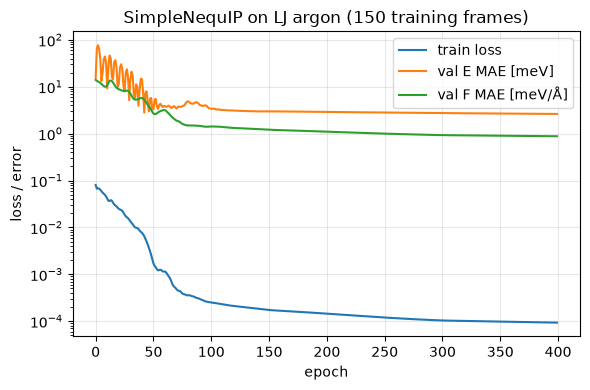

In [7]:
# Visualize the training curves
ax = plot_training_curves(history)
ax.set_title("SimpleNequIP on LJ argon (150 training frames)")
ax.figure.tight_layout()
plt.show()

The force parity plot compares predicted forces against reference forces

validation energy MAE:   2.63 meV  (0.33 meV/atom)
validation force  MAE:   0.88 meV/Å  (force RMS in data: 32 meV/Å)


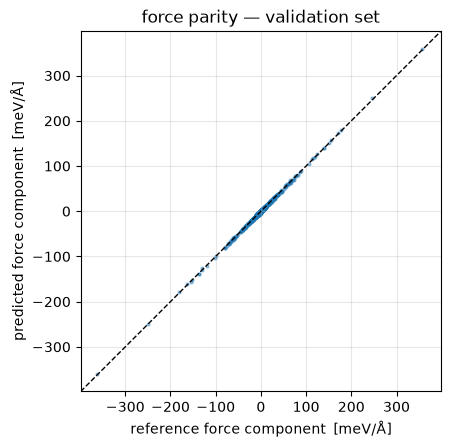

In [8]:
# Set the model to evaluation mode
model.eval()

# Compute the predicted energies and forces for the validation data using the
# trained model
E_hv, F_hv = energy_and_forces(model, pos_va.clone(), edges_va, batch=batch_va)

# Compute the mean absolute error (MAE) for energy and force predictions on the
# validation set
mae_E = (E_hv - E_va).abs().mean().item()
mae_F = (F_hv - F_va).abs().mean().item()

# Print the validation energy and force MAE, scaled to meV and meV/Å
# respectively, along with the per-atom energy MAE
print(f"validation energy MAE: {1000 * mae_E:6.2f} meV  ({1000 * mae_E / n_atoms:.2f} meV/atom)")
print(f"validation force  MAE: {1000 * mae_F:6.2f} meV/Å  "
      f"(force RMS in data: {1000 * F_va.pow(2).mean().sqrt():.0f} meV/Å)")

# Create a force parity plot to visualize the agreement between predicted and
# reference forces
fig, ax = plt.subplots(figsize=(4.6, 4.6))
f_ref = F_va.cpu().numpy().ravel() * 1000
f_pred = F_hv.detach().cpu().numpy().ravel() * 1000
ax.scatter(f_ref, f_pred, s=4, alpha=0.4)
lim = np.abs(f_ref).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("reference force component  [meV/Å]")
ax.set_ylabel("predicted force component  [meV/Å]")
ax.set_title("force parity — validation set")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### Equivariance survives the training

Symmetry in NequIP is built into the architecture and not learned. So, we expect
that it remains untouched by the training. A quick re-check of the pre-trained
weights in float64 gives us the verification we need

In [9]:
# Get the trained model in float64 and evaluate it on the reference geometry to
# check that equivariance is preserved after training
model64 = copy.deepcopy(model).cpu().to(torch.float64).eval()

# Compute the energy and forces for the reference geometry using the trained
# model
E0, F0 = energy_and_forces(model64, pos0.clone(), edges0)

# Improper random rotation
g = -o3.rand_matrix(dtype=torch.float64)

# Random translation
t = torch.randn(3, dtype=torch.float64)

# Compute the energy and forces for the transformed geometry using the trained
# model. The positions are transformed by the rotation and translation, and the
# edges are updated accordingly.
Eg, Fg = energy_and_forces(model64, pos0 @ g.T + t, edges0)

# Check that the energy and forces are equivariant under the transformation. The
# energy should be invariant, and the forces should transform according to the
# rotation matrix. The maximum absolute differences are printed to verify this.
print(f"Trained model:  |ΔE| = {(Eg - E0).abs().max():.2e},  "
      f"|ΔF| = {(Fg - F0 @ g.T).abs().max():.2e}   --> equivariance preserved")

Trained model:  |ΔE| = 5.03e-13,  |ΔF| = 5.46e-12   --> equivariance preserved


## The rematch, part three: rMD17 aspirin

In Lessons 07b-07c, we conducted a set of controlled experiment, camparing the
performance of `SchNet` against `SimpleDimeNet`, first on LJ argon dataset
(where distances suffice), then on aspirin rMD17 dataset (where angles matter).
The `SimpleNequIP` model promises angular expressiveness **without** the
$O(Nk^2)$ triplet enumeration. 

We reuse Lesson 07c's protocol for consistency: The official rMD17, split into
(150 train / 50 validation frames), $r_\mathrm{cut} = 5$ Å, mini-batches of 25
frames, Adam optimizer with cosine annealing, training for 600 epochs, the same
loss with $\rho = 1$, and the same per-atom mean shift of the energies. There is
one exception: the learning rate is $10^{-2}$ instead of $3\times10^{-3}$.

We should also note that Lesson 07c's hyperparameters were tuned for the
invariant baselines, and the tensor-product network traied visibly slower there
(it reached only $\approx$ 121 meV/Å force MAE using the same budget). Each
architecture adopted a learning rate that worked for its own case while every
other knob remained identical. Nonethless, the aspirin dataset brought a new
requirement for the models: three chemical elements (i.e., H, C, and O) compared
to one (i.e., Ar). The species one-hot encoding (`n_species=3`) now does the
real work, whereas for argon, the initial embedding was only a constant.

In [ ]:
# Lesson 07c's data protocol: official rMD17 split 01, r_cut = 5 Å, per-atom mean shift
train_asp, val_asp, z_asp = load_rmd17("aspirin", n_train=150, n_val=50)

# Species mapping: {1:0, 6:1, 8:2}
species_map = {int(Z): s for s, Z in enumerate(torch.unique(z_asp).tolist())}

# Convert the atomic numbers in z_asp to species indices using the species_map.
# This creates a tensor of species indices corresponding to each atom in the
# aspirin molecule.
species_asp = torch.tensor([species_map[int(Z)] for Z in z_asp])

# Set the number of atoms and the cutoff radius for the aspirin dataset
n_atoms_asp, r_cut_asp = len(z_asp), 5.0

# Compute the per-atom mean energy shift for the aspirin dataset. This is used to
# normalize the energies during training.
eps_bar = np.mean([f["energy"] for f in train_asp]) / n_atoms_asp

# Define a collate function for the aspirin dataset that includes species
# indices and the per-atom mean shift. This function takes a list of frames and
# returns the concatenated positions, edges, species indices, batch vector,
# energies (with mean shift), and forces.
def collate_asp(frame_list, dtype=torch.float32):
    '''collate() plus species indices and the per-atom mean shift, at r_cut = 5 Å.'''
    
    # Concatenate positions, forces, and energies into single tensors
    pos = torch.cat([f["pos"] for f in frame_list]).to(dtype)
    F = torch.cat([f["forces"] for f in frame_list]).to(dtype)
    E = torch.tensor([f["energy"] - len(f["pos"]) * eps_bar for f in frame_list], dtype=dtype)
    
    # Build the edge index, batch vector, and species indices for the
    # disconnected graph
    spec = species_asp.repeat(len(frame_list))
    edges, batch, offset = [], [], 0
    for k, f in enumerate(frame_list):
        edges.append(radius_graph(f["pos"], r_cut_asp) + offset)
        batch.append(torch.full((f["pos"].shape[0],), k, dtype=torch.long))
        offset += f["pos"].shape[0]
    
    # Return the concatenated positions, edges, species indices, batch vector,
    # energies, and forces.
    return pos, torch.cat(edges, dim=1), spec, torch.cat(batch), E, F

# Lesson 07c's training protocol: mini-batches of 25 frames
batches_asp = [tuple(x.to(device) for x in collate_asp(train_asp[i:i + 25]))
               for i in range(0, len(train_asp), 25)]

# Collate the validation frames into a single batch and move it to the device
val_batch_asp = tuple(x.to(device) for x in collate_asp(val_asp))

# Compute the average number of neighbors for the aspirin dataset using the
# radius_graph function. This is used to inform the model about the expected
# number of neighbors during training.
avg_nn_asp = float(np.mean([radius_graph(f["pos"], r_cut_asp).shape[1] / n_atoms_asp
                            for f in train_asp]))

# Print information about the aspirin dataset, including the number of atoms,
# the number of mini-batches, and the average number of neighbors.
print(f"Aspirin: {n_atoms_asp} atoms (H/C/O), {len(batches_asp)} mini-batches of 25 frames, "
      f"avg neighbors {avg_nn_asp:.1f}")

In [ ]:
torch.manual_seed(0)
model_asp = SimpleNequIP(r_cut=r_cut_asp, n_species=3,
                         avg_num_neighbors=avg_nn_asp).to(device)
with torch.no_grad():                       # same initialization recipe as for argon
    E_flat = torch.cat([b[4] for b in batches_asp])
    F_flat = torch.cat([b[5] for b in batches_asp])
    model_asp.energy_shift.fill_((E_flat / n_atoms_asp).mean().item())
    model_asp.energy_scale.fill_(F_flat.pow(2).mean().sqrt().item())
print(f"parameters: {sum(p.numel() for p in model_asp.parameters()):,}")

optimizer = torch.optim.Adam(model_asp.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600)
t0 = time.time()
for epoch in range(600):
    model_asp.train()
    for pos_b, edges_b, spec_b, batch_b, E_b, F_b in batches_asp:
        optimizer.zero_grad()
        E_hat, F_hat = energy_and_forces(model_asp, pos_b.clone(), edges_b,
                                         species=spec_b, batch=batch_b)
        # Lesson 07c's loss with rho = 1
        loss = ((E_hat - E_b) ** 2).mean() + ((F_hat - F_b) ** 2).sum(dim=-1).mean()
        loss.backward()
        optimizer.step()
    scheduler.step()
    if epoch % 100 == 0 or epoch == 599:
        model_asp.eval()
        pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp
        E_hv, F_hv = energy_and_forces(model_asp, pos_v.clone(), edges_v,
                                       species=spec_v, batch=batch_v)
        print(f"epoch {epoch:3d} | val E MAE {1e3 * (E_hv - E_v).abs().mean().item() / n_atoms_asp:6.2f} meV/atom"
              f" | val F MAE {1e3 * (F_hv - F_v).abs().mean().item():7.2f} meV/Å"
              f" | {time.time() - t0:6.1f} s")
dt_asp = time.time() - t0
print(f"total training time: {dt_asp:.0f} s on {device}")

In [ ]:
model_asp.eval()
pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp
E_hv, F_hv = energy_and_forces(model_asp, pos_v.clone(), edges_v,
                               species=spec_v, batch=batch_v)
e_nequip = 1e3 * (E_hv - E_v).abs().mean().item() / n_atoms_asp
f_nequip = 1e3 * (F_hv - F_v).abs().mean().item()

# Lesson 07c's table, completed with today's third row
print(f"{'val MAE, rMD17 aspirin':>24} | {'E [meV/atom]':>13} | {'F [meV/Å]':>10} | {'s/epoch':>8}")
print(f"{'SchNet (07c)':>24} | {2.35:>13.2f} | {128.61:>10.2f} | {0.09:>8.2f}")
print(f"{'SimpleDimeNet (07c)':>24} | {1.99:>13.2f} | {97.20:>10.2f} | {0.11:>8.2f}")
print(f"{'SimpleNequIP':>24} | {e_nequip:>13.2f} | {f_nequip:>10.2f} | {dt_asp / 600:>8.2f}")

# The same architecture on both datasets, each error against its dataset's force scale
f_rms_argon = 1e3 * F_va.pow(2).mean().sqrt().item()
f_rms_asp = 1e3 * F_v.pow(2).mean().sqrt().item()
print(f"\n{'SimpleNequIP, forces':>24} | {'MAE [meV/Å]':>11} | {'data RMS':>8} | relative")
print(f"{'LJ argon':>24} | {1e3 * mae_F:>11.2f} | {f_rms_argon:>8.0f} | {1e3 * mae_F / f_rms_argon:8.1%}")
print(f"{'rMD17 aspirin':>24} | {f_nequip:>11.2f} | {f_rms_asp:>8.0f} | {f_nequip / f_rms_asp:8.1%}")

### Reading the result

- **The paper's ordering reproduces at course scale.** With the species one-hot
  as the only architectural change, SimpleNequIP posts the best numbers of the
  three-lesson tournament on both observables at the same 150-frame budget:
  1.51 meV/atom and 85 meV/Å against SimpleDimeNet's 1.99 and 97 and SchNet's
  2.35 and 129. The $l > 0$ features deliver the angular resolution that
  SimpleDimeNet buys with explicit triplets — and a little more — on pairwise
  messages alone.

- **The cost column is honest too.** At $\approx$ 0.8 s/epoch against the
  baselines' $\approx$ 0.1 s, SimpleNequIP is the slowest model in the table.
  The message *count* scales as $O(Nk)$ rather than $O(Nk^2)$, but each message
  carries a tensor product, which costs far more than a scalar filter. At 21
  atoms the constant factor wins; the scaling argument pays off at thousands of
  atoms — which is exactly the regime Lesson 09 (Allegro) chases.

- **Same machinery, harder problem.** Relative to each dataset's force scale,
  the error is 2.8% on LJ argon and 6.8% on aspirin. Nothing about the model
  changed between the two experiments except `n_species` and the data pipeline:
  the architecture built for a pairwise toy potential moved to DFT-quality
  molecular forces by swapping the dataset.

## Export for Lesson 11

Lesson 11 wraps this model as an ASE calculator and runs molecular dynamics. It
needs two files in `notebooks/artifacts/`:

1. `nequip_model.py` — the model *source code*, already written by Lesson 08b.
2. `nequip_lj_argon.pt` — the trained `state_dict` plus the hyperparameter dict,
   written below.

We export the **argon** model: Lesson 11 compares the learned dynamics against the
exact Lennard-Jones potential that generated the data, which is only possible for
the toy system.

In [ ]:
art_dir = pathlib.Path("artifacts")
art_dir.mkdir(exist_ok=True)
checkpoint = {
    "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
    "hparams": model.hparams,
    "info": {"dataset": "make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)",
             "val_energy_mae_eV": mae_E, "val_force_mae_eV_per_A": mae_F,
             "units": "eV, Å", "source": "08c_nequip_training.ipynb"},
}
torch.save(checkpoint, art_dir / "nequip_lj_argon.pt")
print(f"saved {art_dir / 'nequip_lj_argon.pt'} "
      f"({(art_dir / 'nequip_lj_argon.pt').stat().st_size / 1024:.0f} kB)")

### Round-trip check

When we export a model artifact, we rebuild it again from its checkpoint which
includes hyperparameters plus weights. Doing so, we want to make sure the loaded
model artifact can reproduce the trained model's predictions exactly, with no
reference to a specific notebook state.

In [ ]:
ckpt = torch.load(art_dir / "nequip_lj_argon.pt", weights_only=True)
model_reloaded = SimpleNequIP(**ckpt["hparams"])
model_reloaded.load_state_dict(ckpt["state_dict"])
model_reloaded.eval()

model_cpu = copy.deepcopy(model).cpu().eval()
pos_check = val_frames[0]["pos"].to(torch.float32)
edges_check = radius_graph(pos_check, r_cut)
E_a, F_a = energy_and_forces(model_cpu, pos_check.clone(), edges_check)
E_b, F_b = energy_and_forces(model_reloaded, pos_check.clone(), edges_check)

assert torch.allclose(E_a, E_b, atol=1e-7) and torch.allclose(F_a, F_b, atol=1e-7)
print(f"reloaded model reproduces predictions:   (E = {E_a.item():+.5f} eV vs reference "
      f"{val_frames[0]['energy']:+.5f} eV)")

## The production `nequip` package

For real research, use the reference implementation by the paper's authors — [github.com/mir-group/nequip](https://github.com/mir-group/nequip) (`pip install nequip`):

- config-file driven training (`nequip-train config.yaml`) with all the pieces we simplified: per-species scale/shift & skip weights, EMA weights, plateau LR scheduling, early stopping;
- proper periodic-boundary neighbor lists, multi-element datasets, streaming data loaders;
- deployment: `nequip-compile` produces TorchScript/compiled models for LAMMPS (`pair_style nequip`) and ASE, for production MD at scale;
- the same group's [Allegro](https://github.com/mir-group/allegro) (Lesson 09) plugs into the same infrastructure.

The original training configurations from the paper are published at [github.com/mir-group/nequip-input-files](https://github.com/mir-group/nequip-input-files) — a good reference for realistic hyperparameters (compare our Lesson 08a, Section 11).

## Summary

- Trained `SimpleNequIP` on 150 frames of LJ argon with the paper's joint loss (Eq. 9, $\lambda_E{:}\lambda_F = 1{:}N^2$); validation force MAE landed at a fraction of a meV/Å — about 2.8% of the force scale in the data — in well under two minutes of GPU time.
- **Equivariance survived training**, as it must: the check that passed on random weights in Lesson 08b passes on trained weights to the same $10^{-13}$ tolerance.
- **The rematch:** on rMD17 aspirin under Lesson 07c's protocol (learning rate aside), SimpleNequIP reached 1.51 meV/atom and 85 meV/Å validation MAE — ahead of both SchNet (2.35, 128.6) and SimpleDimeNet (1.99, 97.2) — with pairwise messages only, at the price of the slowest epochs in the table.
- Exported `artifacts/nequip_lj_argon.pt` (weights + hyperparameters) and verified that the checkpoint alone rebuilds the trained model.

**Next**: [Lesson 09a](09a_allegro_theory.ipynb) — Allegro, which achieves equivariance *without* message passing, and why that matters for scalability. In [Lesson 11](11_molecular_dynamics_ase.ipynb) the checkpoint exported here drives real MD through ASE.

## Exercises

**1. Invariant baseline.** Rebuild the model with `l_max=0` (hidden irreps `16x0e + 16x0o` — set `mul1=mul2=0` or adapt `irreps_hidden`) and retrain with the same budget. Compare validation force MAE against the equivariant model. For pairwise LJ data the gap is modest — why would you expect it to grow on DFT data for molecules (think about what $l \ge 1$ messages encode)?

<details><summary>Solution sketch</summary>

Pass `l_max=0` (the `irreps_hidden` expression then contains no $l>0$ terms, and `o3.Irreps.spherical_harmonics(0)` reduces the filters to `1x0e`): the convolution collapses to SchNet-style scalar messages weighted by $R(r)$. LJ argon energies depend only on pair distances, which scalar filters capture, so the gap is small. DFT interactions (bond angles, dihedrals, polarization) require correlating *directions* of several neighbors; $l\ge 1$ features carry exactly that information natively (Lesson 08a, Section 10), while an invariant network must reconstruct it indirectly over several layers of distance overlaps. The aspirin half of this lesson is that prediction, tested.</details>

**2. Learned Bessel roots.** Compare `model.basis.b_pi` after training with its initialization $\pi \cdot (1, 2, \dots, 8)$. Did the radial frequencies move? Plot the trained basis functions (as in Lesson 08b) and interpret: which distance range did training emphasize, given that LJ argon pairs cluster around the potential minimum $2^{1/6}\sigma \approx 3.8$ Å?

<details><summary>Solution sketch</summary>

`(model.basis.b_pi / torch.pi)` typically shifts by a few percent from integers: gradients push the low-frequency components to sharpen resolution near the well minimum / first-neighbor shell (~3.5–4 Å), where most force variation in the data lives. Plot `model.basis(r)` for $r \in [3, 6]$ Å and compare node positions with the initialized basis from Lesson 08b. </details>

**3. How much does the learning rate matter?** The aspirin section deviates from Lesson 07c on exactly one knob: $10^{-2}$ instead of $3\times10^{-3}$. Rerun the aspirin training at $3\times10^{-3}$ and at $5\times10^{-3}$, keeping everything else fixed, and plot the three validation force-MAE curves together. Is the tensor-product network simply slower to converge, or does it reach a different solution?

<details><summary>Solution sketch</summary>

At $3\times10^{-3}$ the model reaches only $\approx$ 121 meV/Å within the 600-epoch budget and its curve is still descending at the end — the deficit is optimization speed, not capacity. At $5\times10^{-3}$ it lands in between ($\approx$ 104 meV/Å). The lesson generalizes: when comparing architectures at a fixed epoch budget, a learning rate tuned for one family can quietly handicap another, so a "fair" comparison holds the protocol fixed *and* gives each model a schedule that works for it — stating the deviation, as we do here. </details>

## Reference

- Batzner et al., *E(3)-equivariant graph neural networks for data-efficient and
  accurate interatomic potentials* (Nat. Commun. **13**, 2453, 2022) — [Batzner
  Nat. Commun. 13 2453 2022](https://doi.org/10.1038/s41467-022-29939-5).